# Python-Einführung – Stochastik
---

## Imports

In Python müssen Bibliotheken zuerst **importiert** werden, bevor man sie benutzen kann.
Das ist wie ein Werkzeugkasten öffnen – die Werkzeuge sind da, aber man muss erst den Deckel aufmachen.

- **pandas** – zum Einlesen und Auswerten von Tabellen
- **numpy** – für mathematische Operationen auf Zahlenreihen
- **matplotlib** – zum Erstellen von Diagrammen

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os

## Datensatz einlesen

`pd.read_csv()` liest eine CSV-Datei ein und speichert sie als **DataFrame** – das ist im Grunde eine Tabelle.

In diesem Beispiel verwenden wir die Kaggle API.

In [111]:
movies = 'danielgrijalvas/movies'

# Download dataset → returns folder path where csv documents are saved
folder = kagglehub.dataset_download(movies)
print(os.listdir(folder))

# automatically picks first csv in folder
csv_file = next(f for f in os.listdir(folder) if f.endswith(".csv"))
print(f'This file will be picked: {csv_file}')

# build full path to csv
file_path = os.path.join(folder, csv_file)

# load file into pandas
df = pd.read_csv(file_path)

['movies.csv']
This file will be picked: movies.csv


### Datensatz anschauen

Bevor man mit Daten arbeitet, schaut man sich immer erst an was überhaupt drin ist.

`len(array)` zeigt die Anzahl der zeilen des datensatzes

`head()` zeigt die ersten 5 zeilen des datensatzes

`columns.tolist()` liefert alle spaltennamen

`describe()` liefert statistische kennzahlen zum datensatz



In [112]:
# Anzahl der Zeilen
print(len(df))

7668


In [113]:
# Die ersten 5 Zeilen anzeigen
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [114]:
# Alle Spaltennamen anzeigen
print(df.columns.tolist())

['name', 'rating', 'genre', 'year', 'released', 'score', 'votes', 'director', 'writer', 'star', 'country', 'budget', 'gross', 'company', 'runtime']


## Statistische Kennzahlen für alle numerischen Spalten

`df.describe()` liefert eine **Übersicht der wichtigsten Kennzahlen** für alle numerischen Spalten im DataFrame.

| Statistik | Bedeutung                                                 |
|-----------|-----------------------------------------------------------|
| **count** | Anzahl der vorhandenen Werte in der Spalte                |
| **mean**  | Durchschnittswert                                         |
| **std**   | Standardabweichung – misst, wie stark die Werte streuen   |
| **min**   | Minimalwert                                               |
| **25%**   | 25. Perzentil (1. Quartil) – 25% der Werte liegen darunter |
| **50%**   | 50. Perzentil (Median) – mittlerer Wert                   |
| **75%**   | 75. Perzentil (3. Quartil) – 75% der Werte liegen darunter |
| **max**   | Maximalwert                                               |

In [115]:
# Statistische Kennzahlen für alle numerischen Spalten
df.describe()

,year,score,votes,budget,gross,runtime
count,7668.000000,7665.000000,7.665000e+03,5.497000e+03,7.479000e+03,7664.000000
mean,2000.405451,6.390411,8.810850e+04,3.558988e+07,7.850054e+07,107.261613
std,11.153508,0.968842,1.633238e+05,4.145730e+07,1.657251e+08,18.581247
min,1980.000000,1.900000,7.000000e+00,3.000000e+03,3.090000e+02,55.000000
25%,1991.000000,5.800000,9.100000e+03,1.000000e+07,4.532056e+06,95.000000
50%,2000.000000,6.500000,3.300000e+04,2.050000e+07,2.020576e+07,104.000000
75%,2010.000000,7.100000,9.300000e+04,4.500000e+07,7.601669e+07,116.000000
max,2020.000000,9.300000,2.400000e+06,3.560000e+08,2.847246e+09,366.000000


## Spalte aus Dataframe auswählen
Bewertungen aus dem Dataframe auswählen

`df["score"]` spalte auswählen

`.dropna()` nullwerte entfernen

`to_numpy()` zu numpy array konvertieren

In [116]:
score_array = df["score"].dropna().to_numpy()

---
## Histogramm der Bewertungen

zeigt wie oft bestimmte Bewertungen vorkommen

Text(0.5, 1.0, 'Verteilung der Scores')

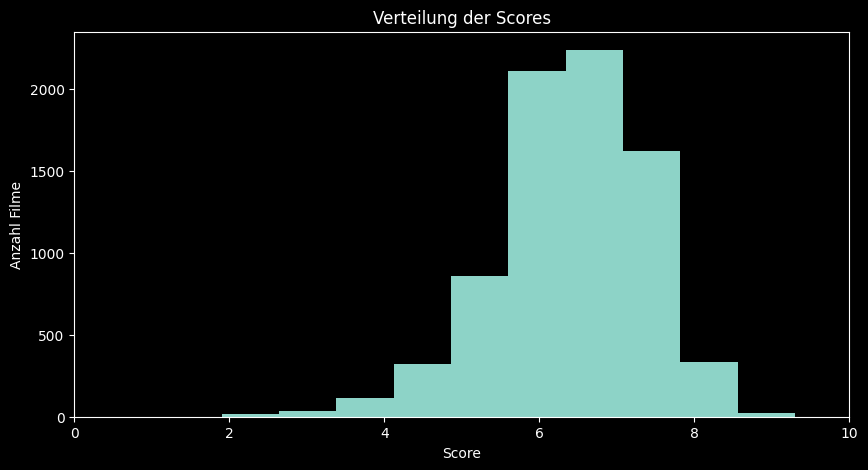

In [117]:
plt.figure(figsize=(10, 5))
plt.hist(score_array)
plt.xlim(0, 10)  # scores liegen zwischen 0 und 10
plt.xlabel("Score")
plt.ylabel("Anzahl Filme")
plt.title("Verteilung der Scores")

## ECDF von Bewertungen

zeigt für jeden Wert deiner Daten, welcher Anteil der Daten kleiner oder gleich diesem Wert ist

Text(0, 0.5, 'Empirische Verteilungsfunktion F(x)')

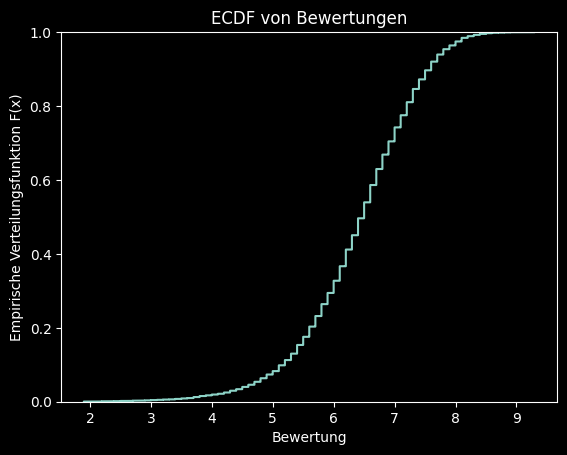

In [118]:
plt.ecdf(score_array)
plt.title("ECDF von Bewertungen")
plt.xlabel("Bewertung")
plt.ylabel("Empirische Verteilungsfunktion F(x)")


Berechnen Sie für die Bewertungen der Filme:

a) das arithmetische Mittel

b) den Median

c) den Modalwert

d) das 25%-Quantil

e) das 75%-Quantil

f) das 90%-Quantil

g) die Varianz

h) die Standardabweichung

i) den Interquartilabstand

j) die Spannweite

In [119]:
from scipy import stats

mean = np.mean(score_array)
median = np.median(score_array)
mode = stats.mode(score_array)[0]
q25 = np.percentile(score_array, 25)
q75 = np.percentile(score_array, 75)
q90 = np.percentile(score_array, 90)
variance = np.var(score_array, ddof=1)
std_dev = np.std(score_array, ddof=1)
iqr = q75 - q25
range = np.max(score_array) - np.min(score_array)

# Ausgabe
print(f"Arithmetisches Mittel: {mean}")
print(f"Median: {median}")
print(f"Modalwert: {mode}")
print(f"25%-Quantil: {q25}")
print(f"75%-Quantil: {q75}")
print(f"90%-Quantil: {q90}")
print(f"Varianz: {variance}")
print(f"Standardabweichung: {std_dev}")
print(f"Interquartilabstand: {iqr}")
print(f"Spannweite: {range}")

Arithmetisches Mittel: 6.390410958904109
Median: 6.5
Modalwert: 6.6
25%-Quantil: 5.8
75%-Quantil: 7.1
90%-Quantil: 7.6
Varianz: 0.9386541238882375
Standardabweichung: 0.9688416402530589
Interquartilabstand: 1.2999999999999998
Spannweite: 7.4


---
## Durchschnittliche Bewertung pro Genre (Advanced)
zeigt die durchschnittliche Bewertung pro Genre

## Spalten auswählen und in NumPy-Arrays umwandeln

Hier wollen wir den **durchschnittlichen `score` pro `genre`** berechnen.

Wir brauchen deshalb nur diese 2 Spalten:
- `genre`
- `score`

Was der Code darunter macht:

1) `daten = df[["genre", "score"]].dropna()`

   Entfernt alle Zeilen, in denen `genre` oder `score` fehlt (`NaN`).

2) Umwandeln in NumPy-Arrays:

   `genre_array` enthält alle Genre-Werte,
   `score_array` enthält alle Score-Werte.

3) `genres = np.unique(genre_array)`:

   Alle Genres kommen hier nur **einmal** vor.

4) `average_ratings`:

   Für jedes Genre wird der Mittelwert der passenden `score`-Werte berechnet und gespeichert.

Am Ende nutzen wir dann `plt.bar(genres, average_ratings)`.


In [120]:
# we only need these 2 columns
daten = df[["genre", "score"]].dropna()

# cnvert columns to NumPy arrays
genre_array = daten["genre"].to_numpy()
score_array = daten["score"].to_numpy()

# x = all genres (only once)
genres = np.unique(genre_array)

# y = average score for each genre
average_ratings = []  # start with an empty list

for genre in genres:
    passende_scores = score_array[genre_array == genre]  # scores of this genre
    durchschnitt = np.mean(passende_scores)              # average
    average_ratings.append(durchschnitt)                 # save average
# Convert list to NumPy array
average_ratings = np.array(average_ratings)


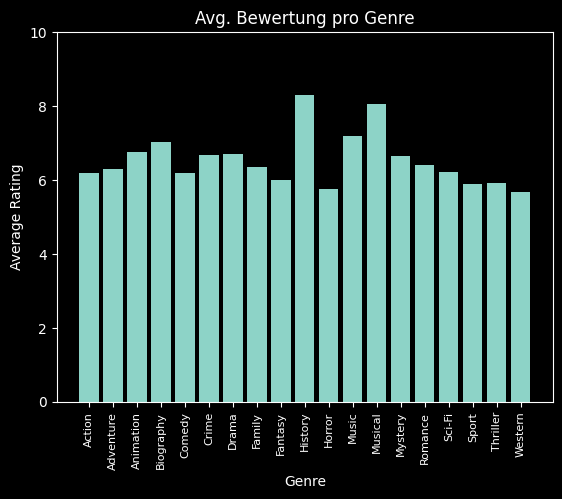

In [121]:
plt.bar(genres, average_ratings)
plt.title("Avg. Bewertung pro Genre")
plt.xlabel("Genre")
plt.xticks(rotation=90, fontsize=8)
plt.ylabel("Average Rating")
plt.ylim(0, 10)  # von 0 bis 10
plt.show()